# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment №2, part 1
## Gradient boosting on temporal data and feature importances

Today we will work with Gradient Boosting library. It is one of the most popular models these days that shows both great quality and performance.

Choises for library are:

* [LightGBM](https://github.com/Microsoft/LightGBM) by Microsoft. Handful and fast.
* [Catboost](https://github.com/catboost/catboost) by Yandex. Tuned to deal well with categorical features.
* [xgboost](https://github.com/dmlc/xgboost) by dlmc. The most famous framework which got very popular on kaggle.

**Dataset**

By default we will work with widely known [Human Actividy Recognition (HAR) dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones). Data is available at UCI repository.

There are available both raw and preprocessed datasets. This time we will use the preprocessed one.
Some simple preprocessing is done for you.

If you want more interpretable data, you can take [Wine quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) (see details below).

Your __ultimate target is to get familiar with one of the frameworks above__ and achieve at least 90% accuracy on test dataset and try to get some useful insights on the features the model paid attention to.

## Part 0. Downloading and preprocessing

The preprocessing is done for you. Let's take a look at the data:

In [1]:
# Download and unpack dataset from UCI
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
!unzip -u "UCI HAR Dataset.zip" "UCI HAR Dataset/train/X_train.txt" "UCI HAR Dataset/train/y_train.txt" \
"UCI HAR Dataset/test/X_test.txt" "UCI HAR Dataset/test/y_test.txt" "UCI HAR Dataset/activity_labels.txt"

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"unzip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
X_train = np.genfromtxt("UCI HAR Dataset/train/X_train.txt")
y_train = np.genfromtxt("UCI HAR Dataset/train/y_train.txt")
print(f"Train set: {X_train.shape}, {y_train.shape}")

X_test = np.genfromtxt("UCI HAR Dataset/test/X_test.txt")
y_test = np.genfromtxt("UCI HAR Dataset/test/y_test.txt")
print(f"Test set: {X_test.shape}, {y_test.shape}")

n_features = X_train.shape[1]

Train set: (7352, 561), (7352,)
Test set: (2947, 561), (2947,)


In [4]:
activity_labels = {}
with open("UCI HAR Dataset/activity_labels.txt", "r") as file:
    for line in file:
        label, name = line.strip().split(" ")
        activity_labels[int(label)] = name

activity_labels

{1: 'WALKING',
 2: 'WALKING_UPSTAIRS',
 3: 'WALKING_DOWNSTAIRS',
 4: 'SITTING',
 5: 'STANDING',
 6: 'LAYING'}

Let's normalize data

In [5]:
data_mean = X_train.mean(axis=0)
data_std = X_train.std(axis=0)

X_train = (X_train - data_mean) / data_std
X_test = (X_test - data_mean) / data_std

The dataset has some duplicating features. Let's remove them

In [6]:
# fmt: off
duplicating_columns = (
    205, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 231, 244, 257, 507, 520, 533, 546,
)
# fmt: on

duplicating_mask = np.isin(range(n_features), duplicating_columns)

In [7]:
X_train_unique = X_train[:, ~duplicating_mask]
X_test_unique = X_test[:, ~duplicating_mask]

X_train_unique.shape, X_test_unique.shape

((7352, 540), (2947, 540))

PCA could be useful in this case. E.g.

In [8]:
from sklearn.decomposition import PCA

In [9]:
pca = PCA(0.99)

X_train_pca = pca.fit_transform(X_train_unique)
X_test_pca = pca.transform(X_test_unique)

X_train_pca.shape, X_test_pca.shape

((7352, 179), (2947, 179))

Text(0, 0.5, 'Principal component 2')

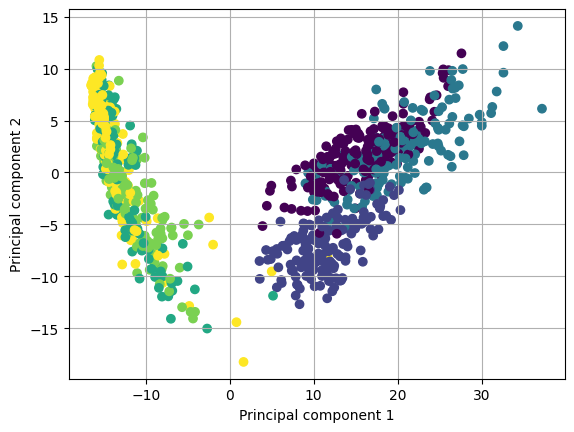

In [10]:
plt.scatter(X_train_pca[:1000, 0], X_train_pca[:1000, 1], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")

Text(0, 0.5, 'Principal component 5')

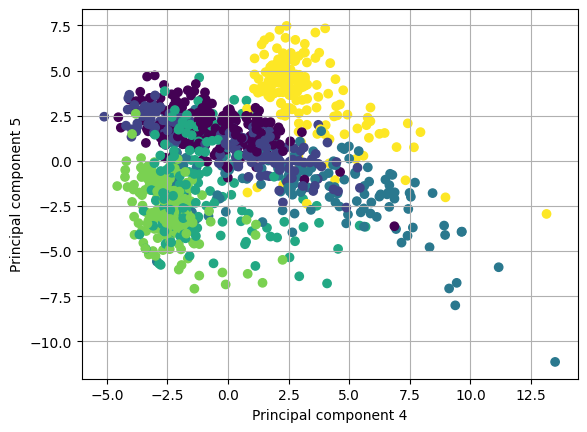

In [11]:
plt.scatter(X_train_pca[:1000, 3], X_train_pca[:1000, 4], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 4")
plt.ylabel("Principal component 5")

### Alternative dataset: Wine quality

Please, take this dataset if you are sure you can preprocess it yourself and ready to work with it's features and results, so it is done on your risk.

However you will have interpretable features which can be analysed with shap in last part

In [12]:
!pip install ucimlrepo

In [13]:
import ucimlrepo as uci

In [14]:
dataset = uci.fetch_ucirepo(id=186)

print(dataset.metadata.name, '\n')
print(dataset.metadata.abstract, '\n')
print(dataset.metadata.additional_info.summary, '\n')

Wine Quality 

Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/). 

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009].  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

These datasets can be viewed as classification or regression tasks.  The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to t

## Part 1. Fit the model.

Despite optimal parameters (e.g. for xgboost) can be found on the web, we still want you to approximate them by yourself.

In this part just check some (3-5) sets of hyperparameters by hand.

In [15]:
# YOUR CODE HERE

# Example: https://rpubs.com/burakh/har_xgb

import xgboost as xgb
from sklearn.model_selection import GridSearchCV

dtrain = xgb.DMatrix(X_train_pca, label=y_train)
dtest = xgb.DMatrix(X_test_pca, label=y_test)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.1, 0.01],
    "subsample": [0.7, 1.0]
}

xgb_model = xgb.XGBClassifier()
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring="accuracy", n_jobs=-1)

y_train_shifted = y_train - 1
y_test_shifted = y_test - 1

grid_search.fit(X_train_pca, y_train_shifted)

print(grid_search.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}


## Part 2. Use hyper parameter tuning system

Use [optuna](https://optuna.org/), [hyperopt](http://hyperopt.github.io/hyperopt/) or any other zero order optimizer to find optimal hyper param set.

In [17]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

X_tr, X_val, y_tr, y_val = train_test_split(X_train_pca, y_train_shifted, test_size=0.2, random_state=42)

def optimizer(trial):
    params = {
    "n_estimators": trial.suggest_int("n_estimators", 50, 150),
    "max_depth": trial.suggest_int("max_depth", 3, 10),
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.4),
    "subsample": trial.suggest_float("subsample", 0.1, 1.0)
    }

    model = xgb.XGBClassifier(**params, objective="multi:softmax", eval_metric="mlogloss", num_class=6, random_state=42, n_jobs=-1)

    model.fit(X_tr, y_tr)
    
    y_pred = model.predict(X_val)

    # accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")

    return f1


In [18]:
study = optuna.create_study(direction="maximize")
study.optimize(optimizer, n_trials=100)

[I 2025-12-16 18:49:35,172] A new study created in memory with name: no-name-71879824-7aaa-4f3e-9db3-56e1d2618505
[I 2025-12-16 18:49:38,693] Trial 0 finished with value: 0.946100958620307 and parameters: {'n_estimators': 78, 'max_depth': 10, 'learning_rate': 0.34610492005900717, 'subsample': 0.1117423765983496}. Best is trial 0 with value: 0.946100958620307.
[I 2025-12-16 18:49:45,150] Trial 1 finished with value: 0.9616185553436477 and parameters: {'n_estimators': 146, 'max_depth': 5, 'learning_rate': 0.15463276374288068, 'subsample': 0.7757991167076053}. Best is trial 1 with value: 0.9616185553436477.
[I 2025-12-16 18:49:49,964] Trial 2 finished with value: 0.9524359978414286 and parameters: {'n_estimators': 140, 'max_depth': 7, 'learning_rate': 0.39971508801571826, 'subsample': 0.9921626402890145}. Best is trial 1 with value: 0.9616185553436477.
[I 2025-12-16 18:49:55,970] Trial 3 finished with value: 0.9691943533303364 and parameters: {'n_estimators': 130, 'max_depth': 8, 'learnin

In [21]:
print(study.best_params)
print(study.best_value)

{'n_estimators': 148, 'max_depth': 3, 'learning_rate': 0.3959649241395755, 'subsample': 0.29269518376173786}
0.9742824739304764


In [ ]:
from sklearn.metrics import f1_score

best_model = xgb.XGBClassifier(**study.best_params, objective="multi:softmax", eval_metric="mlogloss", num_class=6, random_state=42)
best_model.fit(X_train_pca, y_train_shifted)

y_pred = best_model.predict(X_test_pca)

f1 = f1_score(y_test_shifted, y_pred, average="macro")
print(f1)

0.9308071743528075


### Conclusion

Please, write down your thoughts on the experiment results:

The goal was to apply XGBoost to classify human activities into 6 classes. The HAR dataset was preprocessed by standardization, removing duplicates, and PCA, reducing features from 561 to 179. Hyperparameters were tuned manually and with Optuna using macro F1 as the metric. Firstly i used GridSearchCV with a lot of hyperparameters and it took me 90 minutes to decide shut down process and stay with four of them. The final model achieved macro 
F1 ≈ 0.93 on the test set, showing good generalization.

## Part 3. Interpret the model predictions

Please use [shap](https://github.com/slundberg/shap) to build some plots and try to interpret them.

100%|===================| 17676/17682 [03:56<00:00]        

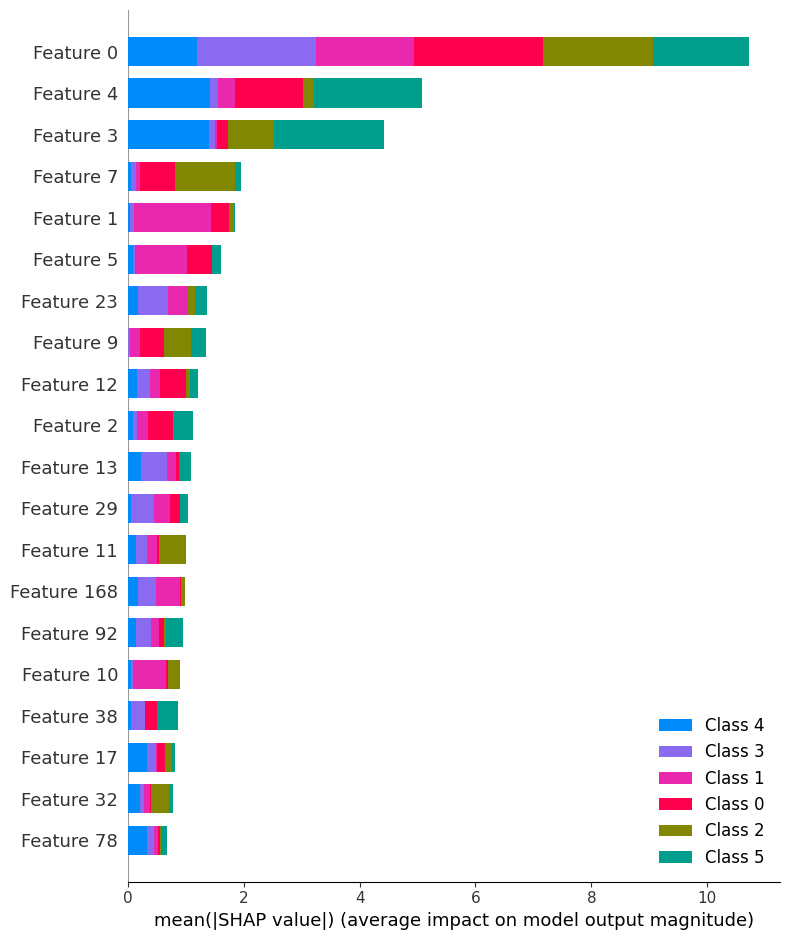

In [27]:
import shap  # noqa: F401


explainer = shap.Explainer(best_model, X_train_pca)
shap_values = explainer(X_test_pca)

shap.summary_plot(shap_values, X_test_pca)

### Conclusion

Your thoughts about the plots and model behaviour:

Feature 0 has the highest impact on predictions, it has influence on multiple classes. Lower-ranked features contribute less to the model output.
